In [1]:
import pandas as pd
from scipy.stats import randint
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
x_train = pd.read_csv(r'C:\Projects_ciência_dados\students_performance\data\processed\x_train.csv')

In [3]:
x_train.columns

Index(['one_hot__gender_female', 'one_hot__gender_male',
       'one_hot__race/ethnicity_group A', 'one_hot__race/ethnicity_group B',
       'one_hot__race/ethnicity_group C', 'one_hot__race/ethnicity_group D',
       'one_hot__race/ethnicity_group E',
       'one_hot__parental level of education_associate's degree',
       'one_hot__parental level of education_bachelor's degree',
       'one_hot__parental level of education_high school',
       'one_hot__parental level of education_master's degree',
       'one_hot__parental level of education_some college',
       'one_hot__parental level of education_some high school',
       'one_hot__lunch_free/reduced', 'one_hot__lunch_standard',
       'one_hot__test preparation course_completed',
       'one_hot__test preparation course_none', 'scaler__math score'],
      dtype='object')

In [4]:
x_test = pd.read_csv(r'C:\Projects_ciência_dados\students_performance\data\processed\x_test.csv')

In [5]:
y_train = pd.read_csv(r'C:\Projects_ciência_dados\students_performance\data\processed\y_train.csv')

In [6]:
y_test = pd.read_csv(r'C:\Projects_ciência_dados\students_performance\data\processed\y_test.csv')

Tunning de parâmetros

 Árvore de decisão

In [7]:
parametros_arvore = {
    "max_depth": randint(10,20),
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,5,10],
    "criterion":["gini", "entropy"]
}

ra = RandomizedSearchCV(estimator=DecisionTreeClassifier(), param_distributions=parametros_arvore, n_jobs=4, verbose=True)
ra.fit(x_train,y_train)
melhores_parametros = ra.best_params_
melhor_resultado = ra.best_score_
print(melhores_parametros)
print(melhor_resultado)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 5, 'min_samples_split': 2}
0.9049999999999999


 Regressão logística

In [8]:
parametros_regression = {
    'C':[1.0,2.0,3.0,4.0],
    'penalty':['l1','l2','elasticnet'],
    'tol':[0.001, 0.0001, 0.00001],
    'fit_intercept':[True, False]
}

re = RandomizedSearchCV(estimator=LogisticRegression(), param_distributions=parametros_regression, n_jobs=4, verbose=True)
re.fit(x_train,y_train)
melhores_parametros = re.best_params_
melhor_resultado = re.best_score_
print(melhores_parametros)
print(melhor_resultado)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'tol': 1e-05, 'penalty': 'l2', 'fit_intercept': True, 'C': 4.0}
0.915


c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
35 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Projects_ciência_dados\s

Random Forest

In [9]:
parametros_random = {
    "n_estimators": randint(100,301), # no randint coloca o maior e menor
    "min_samples_split": randint(10,30),
    "min_samples_leaf": randint(10,30),
    "max_features": ['log2','sqrt'],
    "max_depth": randint(10,20)
}

random = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=parametros_random, n_jobs=4, verbose=True)
random.fit(x_train,y_train)
melhores_parametros = random.best_params_
melhor_resultado = random.best_score_
print(melhores_parametros)
print(melhor_resultado)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


{'max_depth': 11, 'max_features': 'log2', 'min_samples_leaf': 18, 'min_samples_split': 14, 'n_estimators': 181}
0.89875


SVM

In [10]:
parametros_SVM = {
    "C":[1,2,4,5,6],
    "kernel":['poly','rbf','sigmoid','linear']
}

SVM = RandomizedSearchCV(estimator=SVC(), param_distributions=parametros_SVM, n_jobs=4)
SVM.fit(x_train,y_train)
melhores_parametros = SVM.best_params_
melhor_resultado = SVM.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'kernel': 'linear', 'C': 5}
0.91625


c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


XGBoost

In [11]:
parametros_xg = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}


xg = RandomizedSearchCV(estimator=XGBClassifier(), param_distributions=parametros_xg, n_jobs=4)
xg.fit(x_train,y_train)
melhores_parametros = xg.best_params_
melhor_resultado = xg.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}
0.9125


Validação cruzada robusta

In [12]:
bernoulli_resultados = []
random_resultados = []
arvores_resultados = []
logistic_resultados = []
SVM_resultados = []
xgboost_resultados = []


for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    bernouli = BernoulliNB()
    scores = cross_val_score(bernouli, x_train, y_train, cv=kfold, n_jobs=4)
    bernoulli_resultados.append(scores.mean())
    
    random = RandomForestClassifier(max_depth = 11, max_features = 'log2', min_samples_leaf = 25, min_samples_split = 17, n_estimators = 157)
    scores = cross_val_score(random, x_train, y_train, cv=kfold, n_jobs=4)
    random_resultados.append(scores.mean())
    
    arvore = DecisionTreeClassifier(criterion = 'gini', max_depth = 14, min_samples_leaf = 5, min_samples_split = 5)
    scores = cross_val_score(arvore, x_train, y_train, cv=kfold, n_jobs=4)
    arvores_resultados.append(scores.mean())
    
    logistic = LogisticRegression(tol = 0.001, penalty = 'l2', fit_intercept = True, C = 3.0)
    scores = cross_val_score(logistic, x_train, y_train, cv=kfold, n_jobs=4)
    logistic_resultados.append(scores.mean())
    
    SVM = SVC(kernel = 'linear', C = 4)
    scores = cross_val_score(SVM, x_train, y_train, cv=kfold, n_jobs=4)
    SVM_resultados.append(scores.mean())
    
    xgb = XGBClassifier(subsample = 0.8, n_estimators = 200, min_child_weight = 5, max_depth = 9, learning_rate = 0.2, gamma = 0, colsample_bytree = 0.8)
    scores = cross_val_score(xgb, x_train, y_train, cv=kfold, n_jobs=4)
    xgboost_resultados.append(scores.mean())
    

Agrupando os resultados

In [13]:
resultados = pd.DataFrame({
    "random_forest":random_resultados,
    "arvore":arvores_resultados,
    "logistic":logistic_resultados,
    "SVM":SVM_resultados,
    "XGBoost":xgboost_resultados,
    "bernoulli":bernoulli_resultados
})

In [14]:
resultados

,random_forest,arvore,logistic,SVM,XGBoost,bernoulli
0,0.89625,0.88750,0.92000,0.90750,0.90000,0.84875
1,0.89250,0.89500,0.91750,0.91250,0.90500,0.84250
2,0.89375,0.89500,0.91250,0.91125,0.90000,0.84375
3,0.89250,0.89625,0.91625,0.91250,0.91250,0.84625
4,0.89375,0.89250,0.91125,0.90875,0.90625,0.84750
5,0.89375,0.89375,0.91500,0.91250,0.89750,0.84500
6,0.89250,0.89875,0.91750,0.91625,0.90000,0.84500
7,0.88875,0.89125,0.91250,0.91000,0.90625,0.84500
8,0.88875,0.88875,0.91875,0.91750,0.90250,0.84875
9,0.89125,0.89250,0.91125,0.91000,0.89375,0.84875


Regressão logistica tem maior média e bernoulli tem o menor desvio padrão

In [15]:
resultados.describe() 

,random_forest,arvore,logistic,SVM,XGBoost,bernoulli
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.892583,0.893292,0.915375,0.911417,0.901792,0.845458
std,0.003282,0.005624,0.003507,0.003768,0.004003,0.002355
min,0.882500,0.880000,0.907500,0.901250,0.893750,0.841250
25%,0.891250,0.890313,0.913750,0.909062,0.898750,0.843750
50%,0.892500,0.893750,0.915625,0.911250,0.902500,0.845000
75%,0.895000,0.896250,0.917500,0.913750,0.903750,0.847187
max,0.897500,0.905000,0.921250,0.917500,0.912500,0.850000


Bernoulli apresenta o melhor coeficiente de variação

In [16]:
(resultados.std() / resultados.mean()) * 100

random_forest    0.367648
arvore           0.629542
logistic         0.383147
SVM              0.413387
XGBoost          0.443865
bernoulli        0.278591
dtype: float64

Boxplot comparativo

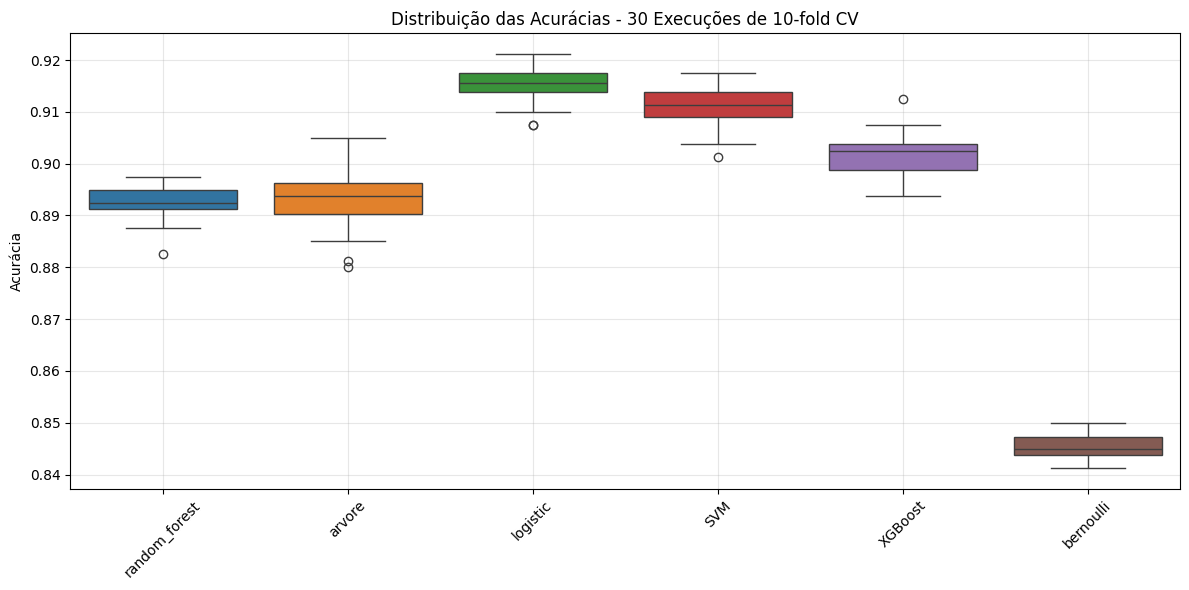

In [17]:

plt.figure(figsize=(12, 6))
df_resultados = pd.DataFrame(resultados)
sns.boxplot(data=df_resultados)
plt.title('Distribuição das Acurácias - 30 Execuções de 10-fold CV')
plt.xticks(rotation=45)
plt.ylabel('Acurácia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 Analisar quais resultados seguem uma distribuição normal

In [18]:
from scipy.stats import shapiro

In [19]:
alpha = 0.05

Todos apresentam distribuição normal, pois o pvalue é maior que alpha

In [20]:
shapiro(random_resultados), shapiro(logistic_resultados), shapiro(arvores_resultados), shapiro(bernoulli_resultados), shapiro(SVM_resultados), shapiro(xgboost_resultados)

(ShapiroResult(statistic=np.float64(0.9414045995815506), pvalue=np.float64(0.09924007233045833)),
 ShapiroResult(statistic=np.float64(0.9531551638708744), pvalue=np.float64(0.20522343433681095)),
 ShapiroResult(statistic=np.float64(0.9562400018364072), pvalue=np.float64(0.24753935259740517)),
 ShapiroResult(statistic=np.float64(0.944536332078535), pvalue=np.float64(0.12053464272731162)),
 ShapiroResult(statistic=np.float64(0.9575945416699283), pvalue=np.float64(0.2685387919714314)),
 ShapiroResult(statistic=np.float64(0.9733772824670255), pvalue=np.float64(0.6350685010604461)))

Gráficos de distribuição normal para confirmar

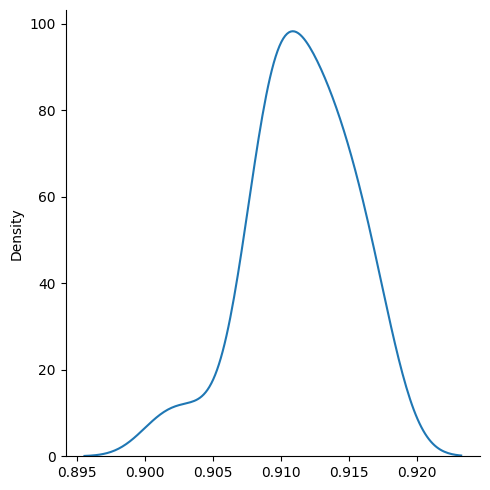

In [21]:
sns.displot(SVM_resultados, kind='kde')

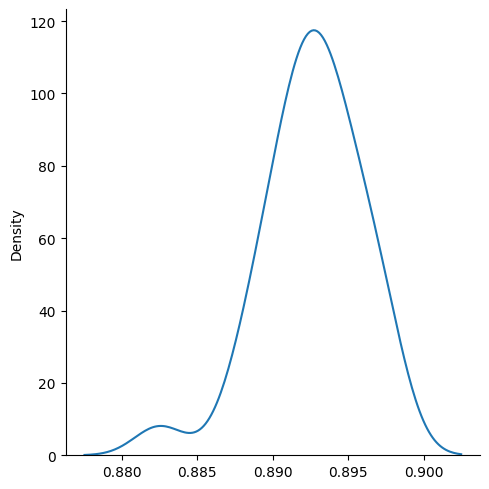

In [22]:
sns.displot(random_resultados, kind='kde')

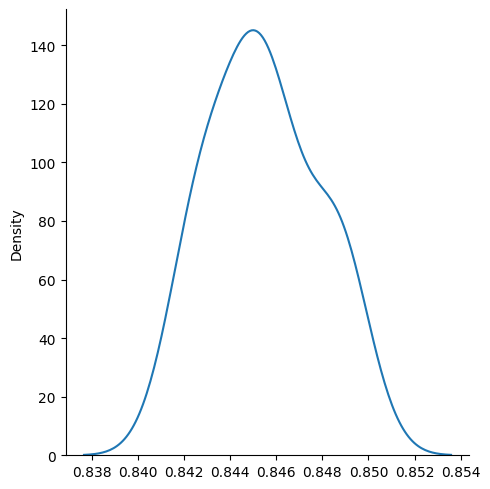

In [23]:
sns.displot(bernoulli_resultados, kind='kde')

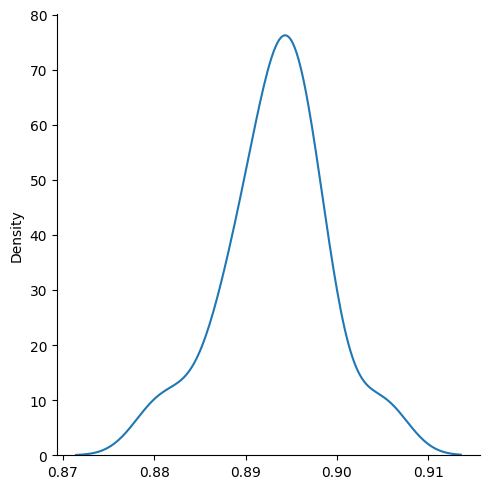

In [24]:
sns.displot(arvores_resultados, kind='kde')

Anova para verificar se a diferença entre os resultados é estatisticamente significativa

In [25]:
from scipy.stats import f_oneway

In [26]:
_, p = f_oneway(random_resultados, arvores_resultados, SVM_resultados, xgboost_resultados, bernoulli_resultados, logistic_resultados)

In [27]:
if p <= alpha:
    print("H0 rejeitada, existe diferença significativa entre os resultados")
else:
    print("H0 aceita, não existe diferença significativa entre os resultados")

H0 rejeitada, existe diferença significativa entre os resultados


In [28]:
p

np.float64(1.0166187138961812e-134)

Aplicação do Tukey

In [29]:
algoritmos_nomes = ['random_forest', 'arvore', 'logistic', 'SVM', 'xg_boost', 'bernoulli']
algoritmos_resultados = [random_resultados, arvores_resultados, logistic_resultados, SVM_resultados, xgboost_resultados, bernoulli_resultados]

In [30]:
resultados_algoritmos = pd.DataFrame({
    'accuracy':np.concatenate(algoritmos_resultados),
    'algoritmos':np.repeat(algoritmos_nomes, [len(arr) for arr in algoritmos_resultados])
})

In [31]:
resultados_algoritmos

,accuracy,algoritmos
0,0.89625,random_forest
1,0.89250,random_forest
2,0.89375,random_forest
3,0.89250,random_forest
4,0.89375,random_forest
...,...,...
175,0.84875,bernoulli
176,0.84250,bernoulli
177,0.84500,bernoulli
178,0.84750,bernoulli


In [32]:
from statsmodels.stats.multicomp import MultiComparison

In [33]:
compara_algoritmos = MultiComparison(resultados_algoritmos['accuracy'], resultados_algoritmos['algoritmos'])

Não há diferença estatística significativa entre random forest e árvore de decisão

In [34]:
teste_estatistico = compara_algoritmos.tukeyhsd()
print(teste_estatistico)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
          SVM        arvore  -0.0181    0.0  -0.021 -0.0152   True
          SVM     bernoulli   -0.066    0.0 -0.0688 -0.0631   True
          SVM      logistic    0.004 0.0016  0.0011  0.0068   True
          SVM random_forest  -0.0188    0.0 -0.0217 -0.0159   True
          SVM      xg_boost  -0.0096    0.0 -0.0125 -0.0067   True
       arvore     bernoulli  -0.0478    0.0 -0.0507 -0.0449   True
       arvore      logistic   0.0221    0.0  0.0192   0.025   True
       arvore random_forest  -0.0007  0.981 -0.0036  0.0022  False
       arvore      xg_boost   0.0085    0.0  0.0056  0.0114   True
    bernoulli      logistic   0.0699    0.0   0.067  0.0728   True
    bernoulli random_forest   0.0471    0.0  0.0442    0.05   True
    bernoulli      xg_boost   0.0563    0.0  0.0534  0.0592   

### Treinamento com dados de teste

Se tem alguém que vai bem e classifica como vai mal: pode dar ajuda desnecessária

Se tem alguém que vai mal e classifica como vai bem: pode deixar de dar ajuda

Portanto, a segunda codição é pior, ou seja, o falso positivo

A métrica de recall para a classe 1 é muito importante

Regressão logística

In [35]:
logistic = LogisticRegression(tol = 0.001, penalty = 'l2', fit_intercept = True, C = 3.0, n_jobs=4)
logistic.fit(x_train, y_train)
previsao_logistic = logistic.predict(x_test)

c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [36]:
print(accuracy_score(y_test, previsao_logistic))

0.92


In [37]:
print(classification_report(y_test, previsao_logistic))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92        99
           1       0.90      0.94      0.92       101

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



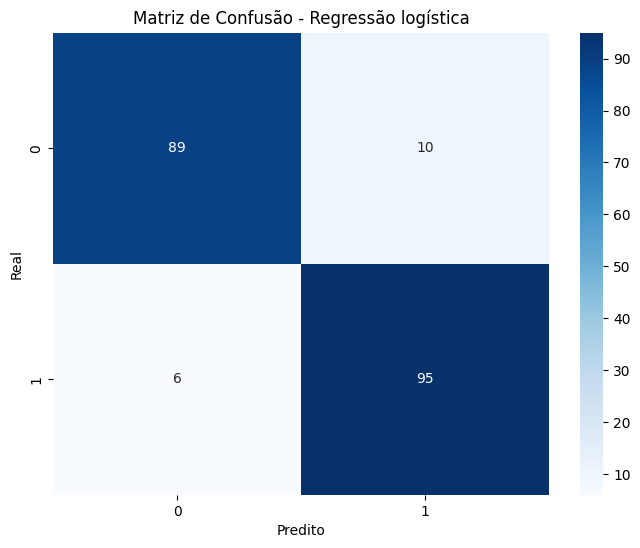

In [38]:
cm = confusion_matrix(y_test, previsao_logistic)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=logistic.classes_, 
            yticklabels=logistic.classes_)
plt.title('Matriz de Confusão - Regressão logística')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [39]:
print(confusion_matrix(y_test, previsao_logistic))

[[89 10]
 [ 6 95]]


Random Forest

In [40]:
random_forest = RandomForestClassifier(max_depth = 11, max_features = 'log2', min_samples_leaf = 25, min_samples_split = 17, n_estimators = 157)
random_forest.fit(x_train, y_train)
previsao_random_forest = random_forest.predict(x_test)

c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [41]:
print(accuracy_score(y_test, previsao_random_forest))

0.9


In [42]:
print(classification_report(y_test, previsao_random_forest))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90        99
           1       0.89      0.91      0.90       101

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



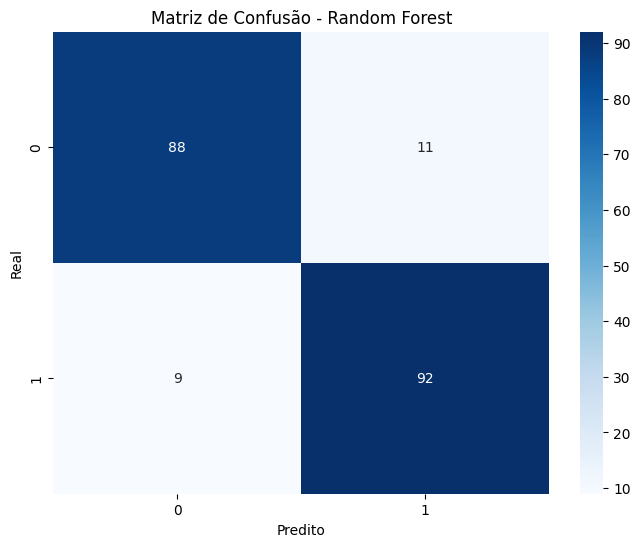

In [43]:
cm = confusion_matrix(y_test, previsao_random_forest)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=random_forest.classes_, 
            yticklabels=random_forest.classes_)
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [44]:
print(confusion_matrix(y_test, previsao_random_forest))

[[88 11]
 [ 9 92]]


 SVM

In [45]:
SVM = SVC(kernel = 'linear', C = 4)
SVM.fit(x_train, y_train)
previsao_SVM = SVM.predict(x_test)

c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [46]:
print(accuracy_score(y_test, previsao_SVM))

0.915


In [47]:
print(classification_report(y_test, previsao_SVM))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91        99
           1       0.90      0.94      0.92       101

    accuracy                           0.92       200
   macro avg       0.92      0.91      0.91       200
weighted avg       0.92      0.92      0.91       200



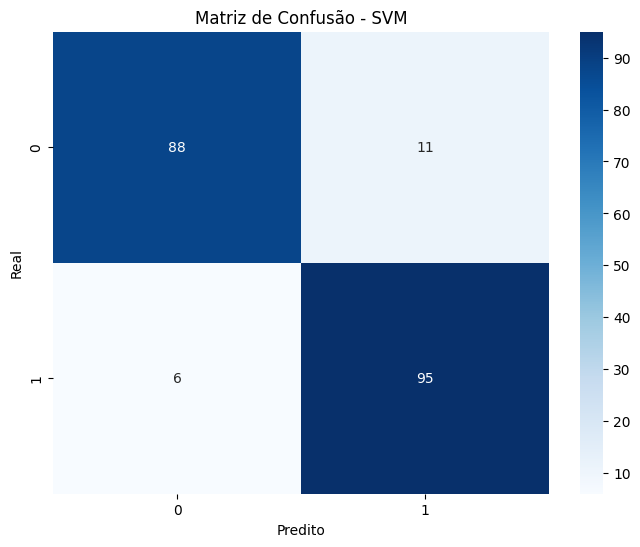

In [48]:
cm = confusion_matrix(y_test, previsao_SVM)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=SVM.classes_, 
            yticklabels=SVM.classes_)
plt.title('Matriz de Confusão - SVM')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

 XGBoost

In [49]:
xgb = XGBClassifier(subsample = 0.8, n_estimators = 200, min_child_weight = 5, max_depth = 9, learning_rate = 0.2, gamma = 0, colsample_bytree = 0.8)
xgb.fit(x_train, y_train)
previsao_xg = xgb.predict(x_test)

In [50]:
print(accuracy_score(y_test, previsao_xg))

0.91


In [51]:
print(classification_report(y_test, previsao_xg))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        99
           1       0.90      0.93      0.91       101

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



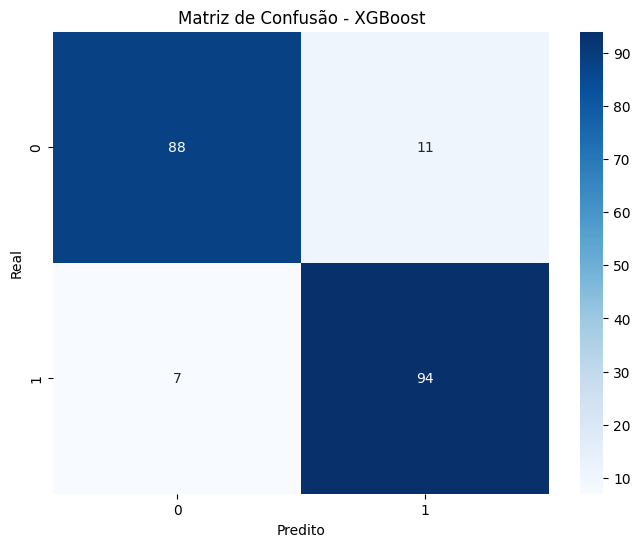

In [52]:
cm = confusion_matrix(y_test, previsao_xg)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=xg.classes_, 
            yticklabels=xg.classes_)
plt.title('Matriz de Confusão - XGBoost')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [53]:
print(confusion_matrix(y_test, previsao_xg))

[[88 11]
 [ 7 94]]


 Árvore de decisão

In [54]:
arvore = DecisionTreeClassifier(criterion = 'gini', max_depth = 14, min_samples_leaf = 5, min_samples_split = 5)
arvore.fit(x_train, y_train)
previsao_arvore = arvore.predict(x_test)

In [55]:
print(accuracy_score(y_test, previsao_arvore))

0.89


In [56]:
print(classification_report(y_test, previsao_arvore))

              precision    recall  f1-score   support

           0       0.87      0.92      0.89        99
           1       0.92      0.86      0.89       101

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



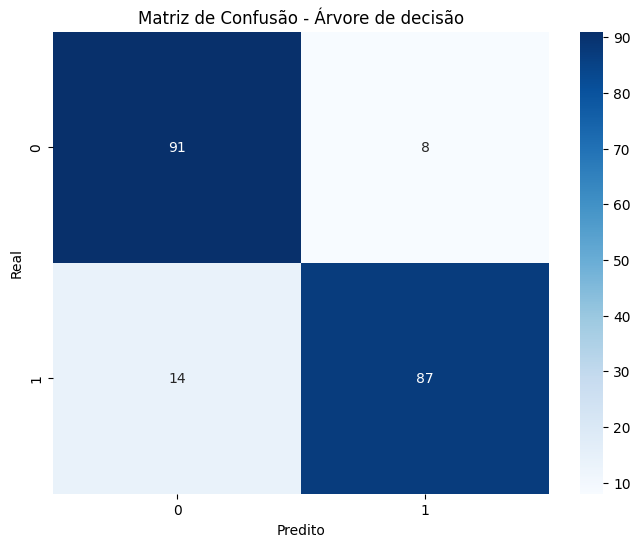

In [57]:
cm = confusion_matrix(y_test, previsao_arvore)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=arvore.classes_, 
            yticklabels=arvore.classes_)
plt.title('Matriz de Confusão - Árvore de decisão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [66]:
importance = pd.DataFrame({
    "importancia_feature":arvore.feature_importances_,
    "feature":x_train.columns
}).sort_values(by="importancia_feature", ascending=False)

In [67]:
importance

,importancia_feature,feature
17,0.798796,scaler__math score
0,0.116802,one_hot__gender_female
16,0.022679,one_hot__test preparation course_none
11,0.013026,one_hot__parental level of education_some college
4,0.009721,one_hot__race/ethnicity_group C
9,0.008903,one_hot__parental level of education_high school
8,0.008875,one_hot__parental level of education_bachelor'...
1,0.008062,one_hot__gender_male
5,0.006808,one_hot__race/ethnicity_group D
14,0.002302,one_hot__lunch_standard


 Bernoulli

In [59]:
bernoulli = BernoulliNB()
bernouli.fit(x_train, y_train)
previsao_bernoulli = bernouli.predict(x_test)

c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [60]:
print(accuracy_score(y_test, previsao_bernoulli))

0.83


In [61]:
print(classification_report(y_test, previsao_bernoulli))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        99
           1       0.84      0.82      0.83       101

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



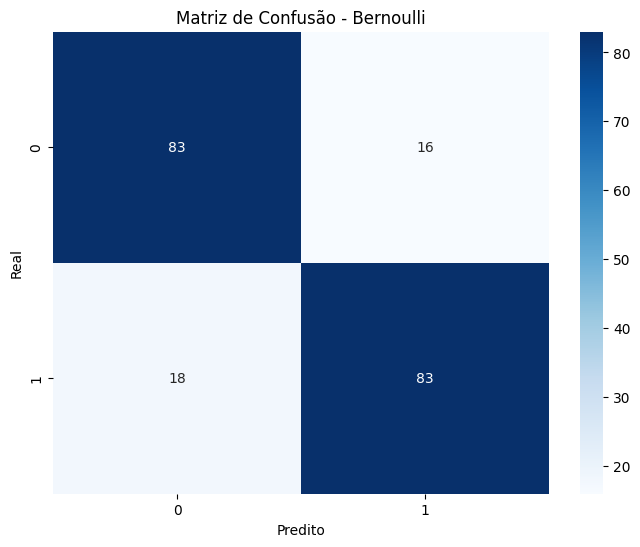

In [62]:
cm = confusion_matrix(y_test, previsao_bernoulli)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=bernouli.classes_, 
            yticklabels=bernouli.classes_)
plt.title('Matriz de Confusão - Bernoulli')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

 A decisão final ficou entre Regressão logística, SVM e XGBoost, pois apresentaram as três maiores acurácias (92%), são estáveis (bons coeficientes de variação) e erram menos em falsos positivos (respeitando a regra de negócio). Mas o melhor é regressão logística, pois apresentou melhor acurácia no treino, é mais estável, mais rápido, menos custoso computacionalmente, menos provável de entrar em overfitting e mais fácil de interpretar